## Grid Search for Bipartite Hyperparameters

This notebook performs a grid search to find the best hyperparameters for a bipartite graph model. We will evaluate different combinations of hyperparameters and select the one that yields the best performance based on a chosen metric.

We will also compare the grid-search results to the analytical optimum derived from the contrastive-loss formulation for the bipartite hyperparameters.

In [1]:
import sys
import numpy as np

sys.path.insert(0, "domain")
sys.path.insert(0, "utils")

# hyperparameters to search over
alphas = np.linspace(0, 1, 21)  # lexical vs. positional weight (1 = lexical only)
lambdas = np.linspace(0, 1, 21)  # epsilon penalty (0 = no penalty, 1 = max penalty)
lexical_normalization_modes = [False, True]  # use global or local lexical normalization

print(f"Alpha:  {len(alphas)} values, range [{alphas[0]:.2f}, {alphas[-1]:.2f}]")
print(f"Lambda: {len(lambdas)} values, range [{lambdas[0]:.2f}, {lambdas[-1]:.2f}]")
print(f"Total combinations: {len(alphas) * len(lambdas) * len(lexical_normalization_modes):,}")

Alpha:  21 values, range [0.00, 1.00]
Lambda: 21 values, range [0.00, 1.00]
Total combinations: 882


## Load Ground Truth Annotations

In [2]:
import json
import pandas as pd
from collections import defaultdict

# ground truth alignments
with open("../transcripts/synthetic/synthetic-ground-truth-alignments.json", encoding="utf-8-sig") as f:
    ground_truth_entries = json.load(f)

# parse string keys to int's in ground truth alignments
for entry in ground_truth_entries:
    entry["alignment"] = {int(k): v for k, v in entry["alignment"].items()}

# load synthetic dataset
df_synthetic_dit_transcripts = pd.read_csv(
    "../transcripts/synthetic/synthetic-dialect-ignorant-transcript.tsv",
    sep="\t", encoding="utf-8-sig"
)
split_map = dict(zip(df_synthetic_dit_transcripts["index"], df_synthetic_dit_transcripts["split"]))

# build training and validation sets based on split
entries_by_split = defaultdict(list)
for entry in ground_truth_entries:
    entries_by_split[split_map.get(entry["index"])].append(entry)

train_entries = entries_by_split["train"]
valid_entries = entries_by_split["valid"]

print(f"Train: {len(train_entries)} pairs")
print(f"Valid: {len(valid_entries)} pairs")

Train: 7 pairs
Valid: 3 pairs


## Imports

In [3]:
from grid_search_bipartite_hyperparameters import (
    grid_search, pivot_f1_grids, print_best_f1_summary,
)

from plot_helpers import plot_grid_search_heatmaps

## Training

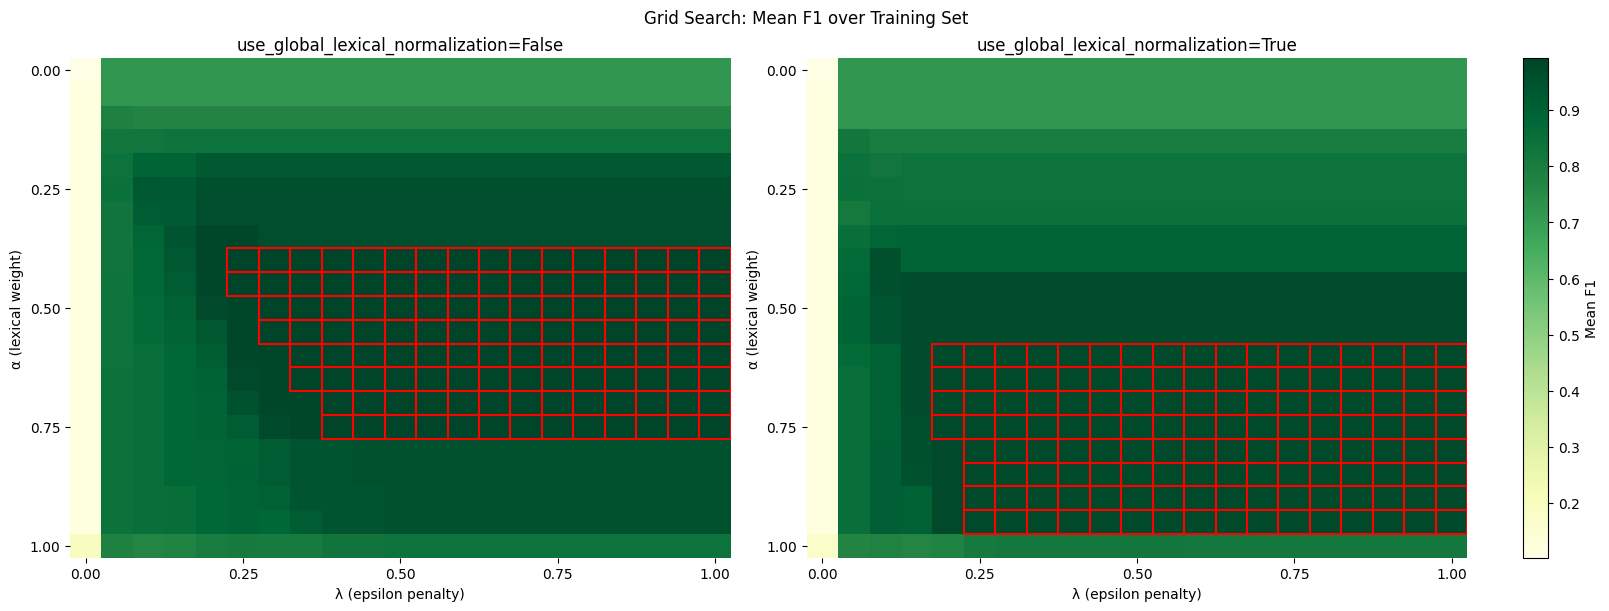

use_global_lexical_normalization=False: Best F1 = 0.993 (116 tied)
  α tied: ['0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75']
  λ tied: ['0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
use_global_lexical_normalization=True: Best F1 = 0.979 (132 tied)
  α tied: ['0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [4]:
df_train = grid_search(train_entries, alphas, lambdas, lexical_normalization_modes)
train_f1_grids = pivot_f1_grids(df_train)

plot_grid_search_heatmaps(
    panels=[(train_f1_grids[mode], f"use_global_lexical_normalization={mode}") for mode in lexical_normalization_modes],
    alphas=alphas,
    lambdas=lambdas,
    subtitle="Grid Search: Mean F1 over Training Set",
)

for mode in lexical_normalization_modes:
    subset = df_train[df_train["use_global_lexical_normalization"] == mode]
    print_best_f1_summary(subset, f"use_global_lexical_normalization={mode}: ")

## Validation

Best normalization mode: use_global_lexical_normalization=False



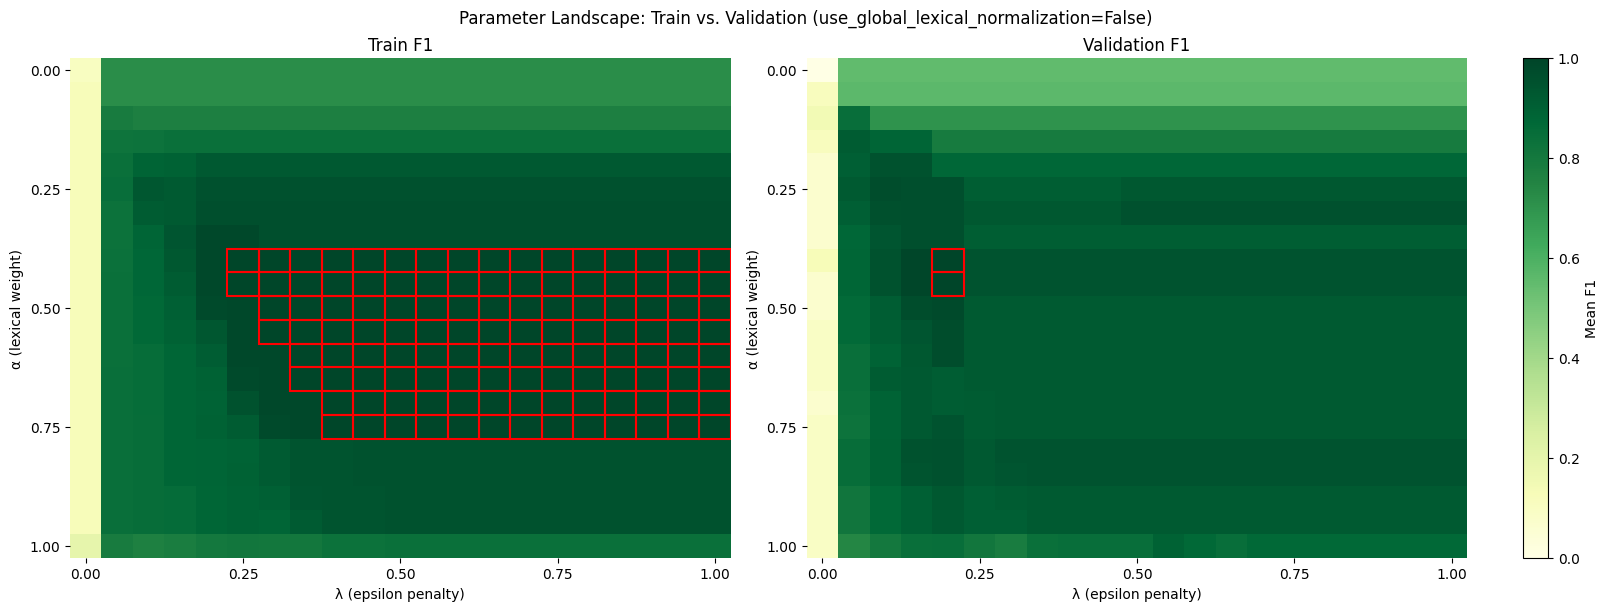

Validation: Best F1 = 1.000 (2 tied)
  α tied: ['0.40', '0.45']
  λ tied: ['0.20']


In [5]:
best_lexical_normalization_mode = max(lexical_normalization_modes, key=lambda m: df_train[df_train["use_global_lexical_normalization"] == m]["f1"].max())
print(f"Best normalization mode: use_global_lexical_normalization={best_lexical_normalization_mode}\n")

df_valid = grid_search(valid_entries, alphas, lambdas, [best_lexical_normalization_mode])
valid_f1_grids = pivot_f1_grids(df_valid)

plot_grid_search_heatmaps(
    panels=[(train_f1_grids[best_lexical_normalization_mode], "Train F1"), (valid_f1_grids[best_lexical_normalization_mode], "Validation F1")],
    alphas=alphas,
    lambdas=lambdas,
    subtitle=f"Parameter Landscape: Train vs. Validation (use_global_lexical_normalization={best_lexical_normalization_mode})",
)

print_best_f1_summary(df_valid, "Validation: ")